#Лабораторна робота №7. Породження зображень змагальними мережами GAN, DCGAN та GAN Вассерштейна


**Виконала** студентка групи КІ-41мп Додонова Марія.

##Завдання

1. Опрацювати матеріали уроків U-24, U-25.

2. У разі використання середовища Google Colab, в меню Runtime (середовище виконання), в пункті Change runtime type обрати в списку Hardware accelerator варіант GPU (графічний процесор) для навчання моделей.  
В подальшому реалізувати збереження контрольних точок під час навчання для відновлення навчання після переривання.

3. Обрати і завантажити набір одноканальних зображень типу MNIST.

**Частина 1**
4. Побудувати і навчити варіаційний автокодувальник і за його допомогою сгенерувати нові зображення, схожі на зображенння заданого набору даних.  
Вивести два графіки: загальної функції втрат та латентної втрати  по епохам навчання.

5.  Оцінити якість побудованого варіаційного автокодувальника.

**Частина 2**
6. Побудувати просту модель GAN:
* Генератор - повнозв'язна мережа, включає один скритий шар і вихідний (output) шар.
* Дискримінатор - повнозв'язна мережа, включає один скритий шар і вихідний (output) шар з одним нейроном.
* Реалізувати прямий прохід генератора і дискримінатора по мережі.
* Обчислити функції втрат генератора і дискримінатора на основі логітів.
* Функцією втрат при навчанні моделі обрати бінарну перехресну ентропію.

7. Виконати попередню обробку набору зображень: привести до типу float32
та змінити діапазон інтенсивностей пікселів на [-1, 1] перед подачею на вхід моделі GAN.  
Створити міні-батчі із зображеннями.

8. Створити випадковий вектор, який має бажаний розподіл: normal (нормальний) або uniform (рівномірний). Цей вектор є входом для генератора для створення нового зображення.

9. Вивести пошарову архітектуру генератора і дискримінатора з кількістю параметрів в кожному шарі.

10. Виконати навчання моделі GAN, використовуючи клас tf.GradientTape() для розрахунку градієнтів функції втрат відносно ваг моделі.  
Окремо навчати генератор і дискримінатор, використовуючи два окремих оптимізатора Adam.  
Навчання бажано проводити на 100 епохах.  
На кожній епосі зберігати окремі зображення сгенеровані генератором з метою їх подальшого друку і аналізу.

11. Вивести графік втрат генератора і дискримінатора по епохам навчання.

12. Побудувати графік середніх ймовірностей реальних і фальшивих зображень, які розраховано дискримінатором на кожній ітерації. Наскільки відміними вони будуть від значення 0,5 ?

13. Надрукувати кілька зображень, які будуються генератором на перших і останніх епохах навчання.

14. Оцінити якість побудованої моделі GAN.

**Частина 3**
15. Побудувати глибоку згорткову модель DCGAN:
* Генератор - глибока згорткова мережа, включає кілька шарів транспонованої згортки і шари пакетної нормалізації між ними.
* Дискримінатор - глибока згорткова мережа, включає кілька шарів традиційної згортки і шари пакетної нормалізації між ними.
* Використати ті самі функції втрат і процедуру навчання, створені для попередньої простої моделі GAN.
* Змість бінарної перехресної ентропії використати функцію втрат на основі відстані Вассерштейна.
* Використати штраф градієнта (gradient penalty, GP).  
За умови двох останніх пунктів модель отримала назву WGAN-with-GP.

16. Наведені вище кроки 7 - 14 повторити для моделі WGAN-with-GP.  Використати оптимізатор Adam.

17. Порівняти якість зображень сгенерованих всіма побудованими моделями: варіаційним автокодувальником, простою GAN та моделлю WGAN-with-GP.  
Які висновки можна зробити на основі аналізу графіків втрат генератора і дискримінатора побудованих моделей GAN?

##Виконання роботи

Завантажимо необхідні бібліотеки.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow import keras
import random

SEED = 42
BATCH_SIZE = 64
LEARNING_RATE = 1e-4

random.seed(SEED)
tf.random.set_seed(SEED)
np.random.seed(SEED)

print("GPUs available:", tf.config.list_physical_devices("GPU"))

GPUs available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


#####3. Обрати і завантажити набір одноканальних зображень типу MNIST.

Оберемо набір даних Fashion MNIST. Завантажимо та передобробимо його. Розділимо на тренувальну, валідаційну та тестову вибірки.

In [ ]:
(X_full_train, y_full_train), (X_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()

X_full_train = X_full_train.astype(np.float32).reshape(-1, 28*28) / 255.0
X_test = X_test.astype(np.float32).reshape(-1, 28*28) / 255.0
y_full_train = y_full_train.astype(np.int32)

# train/val splits
X_train, X_valid, y_train, y_valid = train_test_split(
    X_full_train, y_full_train, test_size=0.1, random_state=SEED)

####**Частина 1**

#####4. Побудувати і навчити варіаційний автокодувальник і за його допомогою сгенерувати нові зображення, схожі на зображенння заданого набору даних. Вивести два графіки: загальної функції втрат та латентної втрати  по епохам навчання.

Побудуємо модель варіаційного автокодувальника. Розміри його внутрішніх шарів кодувальника (і декодувальника, в оберненому порядку) становитимуть 512, 256. Розмір латентного простору - 20. Використовуватимемо функцію активації ELU. Втрату обчислюватимемо як суму втрати реконструкції (Sigmoid Cross Entropy) та модифікованої латентної втрати.

In [ ]:
class VariationalAutoEncoder(keras.Model):
  def __init__(self, input_size=784, hidden_sizes=[512, 256],
               latent_size=20, activation="elu"):
    super().__init__()
    self._input_size = input_size
    self._hidden_sizes = hidden_sizes
    self._latent_size = latent_size
    self._output_size = self._input_size
    self._activation = activation
    self._eps = 1e-10

    self.total_loss_tracker = keras.metrics.Mean(name="total_loss")
    self.kl_loss_tracker = keras.metrics.Mean(name="latent_loss")

    inputs = keras.Input(shape=(self._input_size,))
    x = inputs

    # Encoder
    for size in self._hidden_sizes:
      x = keras.layers.Dense(size, activation=self._activation)(x)

    z_mean = keras.layers.Dense(self._latent_size)(x)
    z_log_var = keras.layers.Dense(self._latent_size)(x)

    def sampling(args):
      z_mean, z_log_var = args
      epsilon = tf.random.normal(shape=tf.shape(z_mean))
      return z_mean + tf.exp(0.5 * z_log_var) * epsilon

    z = keras.layers.Lambda(sampling)([z_mean, z_log_var])
    self._encoder = keras.Model(inputs, [z_mean, z_log_var, z])

    # Decoder
    latent_inputs = keras.Input(shape=(self._latent_size,))
    x = latent_inputs
    for size in reversed(self._hidden_sizes):
      x = keras.layers.Dense(size, activation=self._activation)(x)

    logits = keras.layers.Dense(self._output_size)(x)
    self._decoder = keras.Model(latent_inputs, logits)

  @property
  def metrics(self):
    return [self.total_loss_tracker, self.kl_loss_tracker]

  def _compute_loss(self, data):
    z_mean, z_log_var, z = self._encoder(data)
    logits = self._decoder(z)

    reconstruction_loss = tf.reduce_sum(
        tf.nn.sigmoid_cross_entropy_with_logits(labels=data, logits=logits), axis=1
    )

    std = tf.exp(0.5 * z_log_var)
    kl_loss = 0.5 * tf.reduce_sum(
        tf.square(std) + tf.square(z_mean) - 1 - tf.math.log(self._eps + tf.square(std)), axis=1
    )

    total_loss = tf.reduce_mean(reconstruction_loss + kl_loss)
    return total_loss, tf.reduce_mean(kl_loss)

  def test_step(self, data):
    results = self._step(data)
    return results

  def train_step(self, data):
    if isinstance(data, tuple):
      data = data[0]

    with tf.GradientTape() as tape:
      total_loss, kl_loss = self._compute_loss(data)

    grads = tape.gradient(total_loss, self.trainable_weights)
    self.optimizer.apply_gradients(zip(grads, self.trainable_weights))

    self.total_loss_tracker.update_state(total_loss)
    self.kl_loss_tracker.update_state(kl_loss)

    return {
        "total_loss": self.total_loss_tracker.result(),
        "latent_loss": self.kl_loss_tracker.result()
    }

  def test_step(self, data):
    if isinstance(data, tuple):
      data = data[0]

    total_loss, kl_loss = self._compute_loss(data)

    self.total_loss_tracker.update_state(total_loss)
    self.kl_loss_tracker.update_state(kl_loss)

    return {
        "total_loss": self.total_loss_tracker.result(),
        "latent_loss": self.kl_loss_tracker.result()
    }

  def reconstruct(self, inputs):
    z_mean, z_log_var, z = self._encoder(inputs)
    logits = self._decoder(z)
    return tf.nn.sigmoid(logits)


class VAELossHistoryCallback(keras.callbacks.Callback):
  def on_train_begin(self, logs=None):
    self.model.train_total_loss_history = []
    self.model.train_latent_loss_history = []
    self.model.val_total_loss_history = []
    self.model.val_latent_loss_history = []

  def on_epoch_end(self, epoch, logs=None):
    self.model.train_total_loss_history.append(logs["total_loss"])
    self.model.train_latent_loss_history.append(logs["latent_loss"])
    self.model.val_total_loss_history.append(logs.get("val_total_loss"))
    self.model.val_latent_loss_history.append(logs.get("val_latent_loss"))


class VAEMonitor(keras.callbacks.Callback):
  def __init__(self, num_images=16, latent_size=20):
    self.generated_images_per_epoch = []
    self.fixed_latent_vectors = np.random.normal(size=(num_images, latent_size))

  def on_epoch_end(self, epoch, logs=None):
    generated_images = self.model._decoder.predict(self.fixed_latent_vectors, verbose=0)
    self.generated_images_per_epoch.append(generated_images.reshape((-1, 28, 28, 1)))


class EpochCheckpoint(keras.callbacks.Callback):
  def __init__(self, save_every=10, filepath="checkpoints/model_epoch_{epoch:03d}.h5"):
    super().__init__()
    self.save_every = save_every
    self.filepath = filepath

  def on_epoch_end(self, epoch, logs=None):
    if (epoch + 1) % self.save_every == 0:
      path = self.filepath.format(epoch=epoch + 1)
      self.model.save(path)
      print(f"\nModel saved at epoch {epoch + 1} to {path}")

Навчимо варіаційний автокодувальник з використанням оптимізатора Adam. Під час навчання використаємо VAEMonitor для генерації зображень із фіксованими вхідними векторами на кожній епосі та EpochCheckpoint для збереження моделі кожні 10 епох.

In [ ]:
vae = VariationalAutoEncoder()
vae.compile(optimizer="adam")
history_callback = VAELossHistoryCallback()
monitor_callback = VAEMonitor()
checkpoint_callback = EpochCheckpoint(
    save_every=10,
    filepath="checkpoints/vae_epoch_{epoch:03d}.h5"
)
vae.fit(
    X_train, X_train, epochs=10, validation_data=(X_valid, X_valid),
    callbacks=[history_callback, monitor_callback, checkpoint_callback],
    batch_size=BATCH_SIZE, verbose=1)

Epoch 1/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - latent_loss: 16.0850 - total_loss: 298.3011 - val_latent_loss: 14.2410 - val_total_loss: 253.2317
Epoch 2/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 12s 4ms/step - latent_loss: 14.2294 - total_loss: 251.5022 - val_latent_loss: 14.2350 - val_total_loss: 248.7166
Epoch 3/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - latent_loss: 14.4217 - total_loss: 247.9746 - val_latent_loss: 14.4235 - val_total_loss: 246.5151
Epoch 4/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - latent_loss: 14.4754 - total_loss: 245.9002 - val_latent_loss: 14.6101 - val_total_loss: 246.3415
Epoch 5/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - latent_loss: 14.6095 - total_loss: 244.6361 - val_latent_loss: 14.4247 - val_total_loss: 244.3959
Epoch 6/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - latent_loss: 14.6201 - total_loss: 243.5583 - val_latent_loss: 15.0639 - val_total_loss: 243.5073
Epoch 7/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - latent_loss: 14.6618 - total_los


Model saved at epoch 10 to checkpoints/vae_epoch_010.h5
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - latent_loss: 14.7255 - total_loss: 241.4487 - val_latent_loss: 14.7195 - val_total_loss: 241.8410


Напишемо функцію для візуалізації історії навчання. Виведемо графіки загальної функції втрат та латентної втрати по епохам навчання.

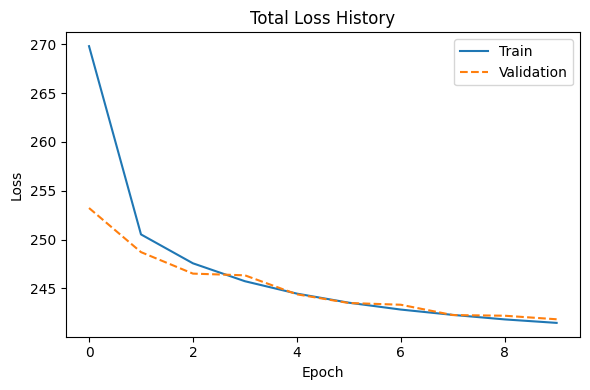

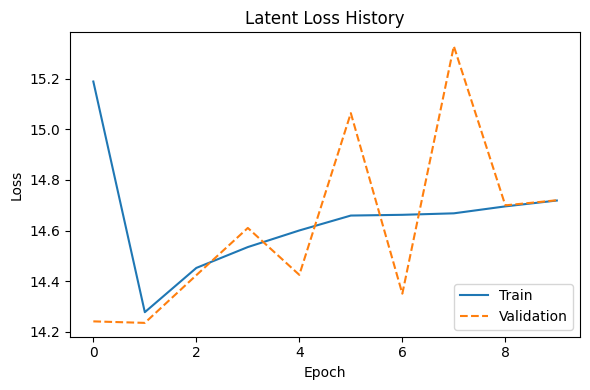

In [ ]:
def plot_losses(train_losses, val_losses=None, title="Loss History"):
  plt.figure(figsize=(6, 4))
  plt.plot(train_losses, label="Train")
  if val_losses is not None:
    plt.plot(val_losses, label="Validation", linestyle="--")
  plt.title(title)
  plt.xlabel("Epoch")
  plt.ylabel("Loss")
  plt.tight_layout()
  plt.legend()
  plt.show()

plot_losses(vae.train_total_loss_history, vae.val_total_loss_history, title="Total Loss History")
plot_losses(vae.train_latent_loss_history, vae.val_latent_loss_history, title="Latent Loss History")

Напишемо функцію для візуалізації згенерованих декодувальником зображень. Відобразимо зображення з першої та останньої епох.

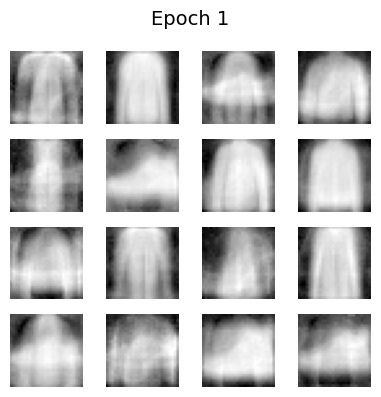

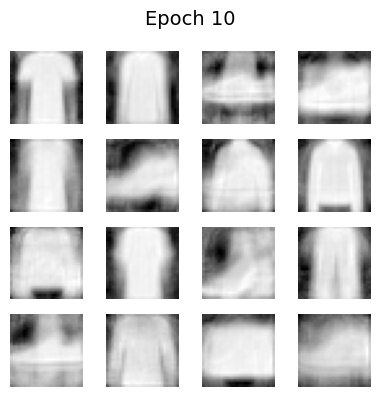

In [ ]:
def plot_generated(generated_images_per_epoch, plot_epochs=None):
  if plot_epochs is None:
    plot_epochs = list(range(len(generated_images_per_epoch)))

  for epoch_idx in plot_epochs:
    images = generated_images_per_epoch[epoch_idx]
    fig = plt.figure(figsize=(4, 4))
    fig.suptitle(f"Epoch {epoch_idx + 1}", fontsize=14)
    for i in range(images.shape[0]):
        plt.subplot(4, 4, i + 1)
        plt.imshow(images[i], cmap="gray")
        plt.axis("off")
    plt.tight_layout()
    plt.show()

plot_generated(
    monitor_callback.generated_images_per_epoch,
    plot_epochs=[0, 9]
)

#####5. Оцінити якість побудованого варіаційного автокодувальника.

Під час навчання загальна втрата помітно зменшилась (майже на 20%), що є показником того, що модель вчиться краще реконструювати зображення. Під час валідації динаміка загальної втрати така сама, що свідчить про відсутність перенавчання. Між втратами при тренуванні та валідації в останніх епохах майже немає розриву, що є хорошою ознакою.

Значення латентної втрати стабілізувались навколо 14.6-14.7. Це означає, що латентний простір залишається нормально розподіленим і тобто не зникає варіативність, що є потрібною властивістю варіаційного автокодувальника.

Згенеровані зображення містять обриси декількох елементів з навчального набору (Fashion MNIST) кожен. Можна розгледіти, що це за предмет, але на одному зображенні таких кілька і їх обриси не дуже чіткі, що є характерним для варіаційних автокодувальників.

Результати можна покращити навчанням на більшій кількості епох, збільшенням розміру латентного простору або ускладненням архітектури автокодувальника.

####**Частина 2**

#####6. Побудувати просту модель GAN:
* Генератор - повнозв'язна мережа, включає один скритий шар і вихідний (output) шар.
* Дискримінатор - повнозв'язна мережа, включає один скритий шар і вихідний (output) шар з одним нейроном.
* Реалізувати прямий прохід генератора і дискримінатора по мережі.
* Обчислити функції втрат генератора і дискримінатора на основі логітів.
* Функцією втрат при навчанні моделі обрати бінарну перехресну ентропію.

Побудуємо просту модель GAN. Генератор є повнозв'язною мережею з одним прихованим та вихідним шаром (з можливістю розширення кількості прихованих шарів). Дискримінатор також є повнозв'язною мережею з одним прихованим шаром (з можливістю збільшення їх кількості) та вихідним шаром з одним нейроном. Реалізуємо прямий прохід генератора і дискримінатора по мережі під час тренування та валідації (тестування).


In [ ]:
class GAN(keras.Model):
  def __init__(self, gen_hidden_sizes=[100], disc_hidden_sizes=[100],
               output_dim=784, dropout_rate=0.5, activation="leaky_relu"):
    super().__init__()
    self.output_dim = output_dim
    self.gen_hidden_sizes = gen_hidden_sizes
    self.disc_hidden_sizes = disc_hidden_sizes
    self.dropout_rate = dropout_rate
    self.activation = activation

    self.generator = self._build_generator()
    self.discriminator = self._build_discriminator()

    self.g_loss_tracker = keras.metrics.Mean(name="generator_loss")
    self.d_loss_tracker = keras.metrics.Mean(name="discriminator_loss")
    self.real_prob_tracker = keras.metrics.Mean(name="real_prob")
    self.fake_prob_tracker = keras.metrics.Mean(name="fake_prob")

  def _build_generator(self):
    model = keras.Sequential(name="generator")
    for units in self.gen_hidden_sizes:
      model.add(keras.layers.Dense(units, use_bias=False))
      model.add(keras.layers.LeakyReLU())
    model.add(keras.layers.Dense(self.output_dim, activation="tanh"))
    return model

  def _build_discriminator(self):
    model = keras.Sequential(name="discriminator")
    for units in self.disc_hidden_sizes:
      model.add(keras.layers.Dense(units))
      model.add(keras.layers.LeakyReLU())
      model.add(keras.layers.Dropout(self.dropout_rate))
    model.add(keras.layers.Dense(1))  # Logits
    return model

  def _update_trackers(self, real_logits, fake_logits, g_loss, d_loss):
    real_probs = tf.sigmoid(real_logits)
    fake_probs = tf.sigmoid(fake_logits)
    self.real_prob_tracker.update_state(tf.reduce_mean(real_probs))
    self.fake_prob_tracker.update_state(tf.reduce_mean(fake_probs))
    self.g_loss_tracker.update_state(g_loss)
    self.d_loss_tracker.update_state(d_loss)

  @property
  def metrics(self):
    return [
        self.g_loss_tracker, self.d_loss_tracker,
        self.real_prob_tracker, self.fake_prob_tracker
    ]

  def compile(self, g_optimizer, d_optimizer, loss_fn):
    super().compile()
    self.g_optimizer = g_optimizer
    self.d_optimizer = d_optimizer
    self.loss_fn = loss_fn

  def train_step(self, data):
    random_latent_vectors, real_images = data

    # Generator
    with tf.GradientTape() as g_tape:
      generated_images = self.generator(random_latent_vectors)
      fake_logits = self.discriminator(generated_images)
      g_loss = self.loss_fn(tf.ones_like(fake_logits), fake_logits)

    g_grads = g_tape.gradient(g_loss, self.generator.trainable_weights)
    self.g_optimizer.apply_gradients(zip(g_grads, self.generator.trainable_weights))

    # Discriminator
    with tf.GradientTape() as d_tape:
      real_logits = self.discriminator(real_images)
      fake_logits = self.discriminator(generated_images)
      d_loss_real = self.loss_fn(tf.ones_like(real_logits), real_logits)
      d_loss_fake = self.loss_fn(tf.zeros_like(fake_logits), fake_logits)
      d_loss = d_loss_real + d_loss_fake

    d_grads = d_tape.gradient(d_loss, self.discriminator.trainable_weights)
    self.d_optimizer.apply_gradients(zip(d_grads, self.discriminator.trainable_weights))

    self._update_trackers(real_logits, fake_logits, g_loss, d_loss)

    return {
        "generator_loss": self.g_loss_tracker.result(),
        "discriminator_loss": self.d_loss_tracker.result(),
        "real_prob": self.real_prob_tracker.result(),
        "fake_prob": self.fake_prob_tracker.result()
    }

  def test_step(self, data):
    random_latent_vectors, real_images = data

    # Generator
    generated_images = self.generator(random_latent_vectors)
    fake_logits = self.discriminator(generated_images)
    g_loss = self.loss_fn(tf.ones_like(fake_logits), fake_logits)

    # Discriminator
    real_logits = self.discriminator(real_images)
    fake_logits = self.discriminator(generated_images)
    d_loss_real = self.loss_fn(tf.ones_like(real_logits), real_logits)
    d_loss_fake = self.loss_fn(tf.zeros_like(fake_logits), fake_logits)
    d_loss = d_loss_real + d_loss_fake

    self._update_trackers(real_logits, fake_logits, g_loss, d_loss)

    return {
        "generator_loss": self.g_loss_tracker.result(),
        "discriminator_loss": self.d_loss_tracker.result(),
        "real_prob": self.real_prob_tracker.result(),
        "fake_prob": self.fake_prob_tracker.result()
    }

  def generate_images(self, z_input):
    generated = self.generator(z_input, training=False)
    return tf.reshape(generated, (-1, 28, 28))


class GANLossHistoryCallback(keras.callbacks.Callback):
  def on_train_begin(self, logs=None):
    self.model.train_g_loss_history = []
    self.model.train_d_loss_history = []
    self.model.val_g_loss_history = []
    self.model.val_d_loss_history = []

  def on_epoch_end(self, epoch, logs=None):
    self.model.train_g_loss_history.append(logs["generator_loss"])
    self.model.train_d_loss_history.append(logs["discriminator_loss"])
    self.model.val_g_loss_history.append(logs.get("val_generator_loss"))
    self.model.val_d_loss_history.append(logs.get("val_discriminator_loss"))


class GANProbHistoryCallback(keras.callbacks.Callback):
  def on_train_begin(self, logs=None):
    self.model.train_real_prob_history = []
    self.model.train_fake_prob_history = []
    self.model.val_real_prob_history = []
    self.model.val_fake_prob_history = []

  def on_epoch_end(self, epoch, logs=None):
    self.model.train_real_prob_history.append(logs["real_prob"])
    self.model.train_fake_prob_history.append(logs["fake_prob"])
    self.model.val_real_prob_history.append(logs.get("val_real_prob"))
    self.model.val_fake_prob_history.append(logs.get("val_fake_prob"))


class GANMonitor(keras.callbacks.Callback):
  def __init__(self, num_images=16, z_dim=20):
    self.num_images = num_images
    self.z_dim = z_dim
    self.generated_images_per_epoch = []
    self.fixed_z = tf.random.normal(shape=(num_images, z_dim))

  def on_epoch_end(self, epoch, logs=None):
    generated_images = self.model.generate_images(self.fixed_z)
    generated_images = (generated_images + 1.0) / 2.0
    self.generated_images_per_epoch.append(generated_images)

#####7. Виконати попередню обробку набору зображень: привести до типу float32 та змінити діапазон інтенсивностей пікселів на [-1, 1] перед подачею на вхід моделі GAN. Створити міні-батчі із зображеннями.

Завантажимо та передобробимо набір даних Fashion MNIST. Розділимо на тренувальну, валідаційну та тестову вибірки.

In [ ]:
# Load data
(X_full_train, y_full_train), (X_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()

# Convert to float32 and scale into [-1, 1]
X_full_train = X_full_train.astype(np.float32).reshape(-1, 28 * 28)
X_test = X_test.astype(np.float32).reshape(-1, 28 * 28)
X_full_train = X_full_train / 255.0 * 2.0 - 1.0
X_test = X_test / 255.0 * 2.0 - 1.0

# Split into train/val
X_train, X_valid, y_train, y_valid = train_test_split(
    X_full_train, y_full_train.astype(np.int32), test_size=0.1, random_state=SEED)

# Wrap into tf.data.Dataset
train_gan_ds = tf.data.Dataset.from_tensor_slices(X_train)
val_gan_ds = tf.data.Dataset.from_tensor_slices(X_valid)
test_gan_ds = tf.data.Dataset.from_tensor_slices(X_test)

#####8. Створити випадковий вектор, який має бажаний розподіл: normal (нормальний) або uniform (рівномірний). Цей вектор є входом для генератора для створення нового зображення.

У роботі використовуватимемо вектори, які мають рівномірний (uniform) розподіл. Створимо вектори та сформуємо остаточні набори даних. Створимо міні-батчі із зображеннями.

In [ ]:
def preprocess(image, z_size=20, mode_z="uniform"):
  if mode_z == "uniform":
    z = tf.random.uniform(shape=(z_size,), minval=-1.0, maxval=1.0)
  elif mode_z == "normal":
    z = tf.random.normal(shape=(z_size,))
  else:
    raise ValueError(f"Unknown mode_z: {mode_z}")
  return z, image

# Create final datasets for GAN and WGANwithGP
train_gan_ds = train_gan_ds.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
train_gan_ds = train_gan_ds.shuffle(10000, seed=SEED)
train_gan_ds = train_gan_ds.batch(BATCH_SIZE, drop_remainder=True).prefetch(tf.data.AUTOTUNE)

val_gan_ds = val_gan_ds.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
val_gan_ds = val_gan_ds.batch(BATCH_SIZE, drop_remainder=True).prefetch(tf.data.AUTOTUNE)

test_gan_ds = test_gan_ds.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
test_gan_ds = test_gan_ds.batch(BATCH_SIZE, drop_remainder=True).prefetch(tf.data.AUTOTUNE)

#####9. Вивести пошарову архітектуру генератора і дискримінатора з кількістю параметрів в кожному шарі.

Відобразимо пошарову архітектуру генератора та дискримінатора.

In [ ]:
gan = GAN()
gan.generator.build(input_shape=(None, 20))
gan.generator.summary()
print()
gan.discriminator.build(input_shape=(None, np.prod(28*28)))
gan.discriminator.summary()

Model: "generator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_7 (Dense)                 │ (None, 100)            │         2,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 784)            │        79,184 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 81,184 (317.12 KB)

 Trainable params: 81,184 (317.12 KB)

 Non-trainable params: 0 (0.00 B)

Model: "discriminator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 100)            │        78,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 78,601 (307.04 KB)

 Trainable params: 78,601 (307.04 KB)

 Non-trainable params: 0 (0.00 B)

#####10. Виконати навчання моделі GAN, використовуючи клас tf.GradientTape() для розрахунку градієнтів функції втрат відносно ваг моделі.  
Окремо навчати генератор і дискримінатор, використовуючи два окремих оптимізатора Adam.  
Навчання бажано проводити на 100 епохах.  
На кожній епосі зберігати окремі зображення сгенеровані генератором з метою їх подальшого друку і аналізу.


Проведемо навчання генератора та дискримінатора з окремими оптимізаторами Adam на 100 епохах. Функцію втрат оберемо BinaryCrossentropy. Після кожної епохи зберігатимемо згенеровані зображення та інші показники моделі. Виконуватимемо збереження самої моделі кожні 25 епох.

In [ ]:
gan = GAN()
gan.compile(
    g_optimizer=tf.keras.optimizers.Adam(LEARNING_RATE),
    d_optimizer=tf.keras.optimizers.Adam(LEARNING_RATE),
    loss_fn=tf.keras.losses.BinaryCrossentropy(from_logits=True)
)
loss_history_callback = GANLossHistoryCallback()
prob_history_callback = GANProbHistoryCallback()
monitor_callback = GANMonitor()
checkpoint_callback = EpochCheckpoint(
    save_every=25,
    filepath="checkpoints/gan_epoch_{epoch:03d}.h5"
)

gan.fit(
    train_gan_ds, epochs=100, validation_data=val_gan_ds,
    callbacks=[loss_history_callback, prob_history_callback, monitor_callback, checkpoint_callback], verbose=1)

Epoch 1/100
843/843 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - discriminator_loss: 0.8974 - fake_prob: 0.5538 - generator_loss: 0.6001 - real_prob: 0.9362 - val_discriminator_loss: 0.5332 - val_fake_prob: 0.3632 - val_generator_loss: 1.0184 - val_real_prob: 0.9273
Epoch 2/100
843/843 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - discriminator_loss: 0.4576 - fake_prob: 0.3153 - generator_loss: 1.1708 - real_prob: 0.9328 - val_discriminator_loss: 0.3297 - val_fake_prob: 0.2318 - val_generator_loss: 1.4836 - val_real_prob: 0.9432
Epoch 3/100
843/843 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - discriminator_loss: 0.3090 - fake_prob: 0.2111 - generator_loss: 1.5848 - real_prob: 0.9391 - val_discriminator_loss: 0.3298 - val_fake_prob: 0.1991 - val_generator_loss: 1.6684 - val_real_prob: 0.9115
Epoch 4/100
843/843 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - discriminator_loss: 0.3288 - fake_prob: 0.1963 - generator_loss: 1.7089 - real_prob: 0.9127 - val_discriminator_loss: 0.3178 - val_fake_prob: 0.1702 - val_generator_loss: 1.9


Model saved at epoch 25 to checkpoints/gan_epoch_025.h5
843/843 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - discriminator_loss: 0.6774 - fake_prob: 0.2375 - generator_loss: 1.7274 - real_prob: 0.7632 - val_discriminator_loss: 0.7421 - val_fake_prob: 0.2806 - val_generator_loss: 1.5375 - val_real_prob: 0.7663
Epoch 26/100
843/843 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - discriminator_loss: 0.7142 - fake_prob: 0.2476 - generator_loss: 1.7007 - real_prob: 0.7545 - val_discriminator_loss: 0.6740 - val_fake_prob: 0.1856 - val_generator_loss: 2.0317 - val_real_prob: 0.7294
Epoch 27/100
843/843 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - discriminator_loss: 0.6528 - fake_prob: 0.2291 - generator_loss: 1.7989 - real_prob: 0.7717 - val_discriminator_loss: 0.6174 - val_fake_prob: 0.1762 - val_generator_loss: 2.0697 - val_real_prob: 0.7494
Epoch 28/100
843/843 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - discriminator_loss: 0.6086 - fake_prob: 0.2185 - generator_loss: 1.8699 - real_prob: 0.7855 - val_discriminator_loss: 0.6379 -


Model saved at epoch 50 to checkpoints/gan_epoch_050.h5
843/843 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - discriminator_loss: 0.6410 - fake_prob: 0.2127 - generator_loss: 1.9956 - real_prob: 0.7903 - val_discriminator_loss: 0.5908 - val_fake_prob: 0.2286 - val_generator_loss: 1.8741 - val_real_prob: 0.8210
Epoch 51/100
843/843 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - discriminator_loss: 0.6280 - fake_prob: 0.2106 - generator_loss: 1.9696 - real_prob: 0.7929 - val_discriminator_loss: 0.6744 - val_fake_prob: 0.2744 - val_generator_loss: 1.6202 - val_real_prob: 0.8189
Epoch 52/100
843/843 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - discriminator_loss: 0.6399 - fake_prob: 0.2124 - generator_loss: 1.9705 - real_prob: 0.7897 - val_discriminator_loss: 0.7051 - val_fake_prob: 0.1682 - val_generator_loss: 2.3469 - val_real_prob: 0.7338
Epoch 53/100
843/843 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - discriminator_loss: 0.6545 - fake_prob: 0.2157 - generator_loss: 1.9854 - real_prob: 0.7861 - val_discriminator_loss: 0.6815 -


Model saved at epoch 75 to checkpoints/gan_epoch_075.h5
843/843 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - discriminator_loss: 0.6531 - fake_prob: 0.2113 - generator_loss: 2.0122 - real_prob: 0.7907 - val_discriminator_loss: 0.6056 - val_fake_prob: 0.1986 - val_generator_loss: 2.1302 - val_real_prob: 0.8002
Epoch 76/100
843/843 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - discriminator_loss: 0.6345 - fake_prob: 0.2099 - generator_loss: 2.0243 - real_prob: 0.7928 - val_discriminator_loss: 0.7010 - val_fake_prob: 0.2143 - val_generator_loss: 1.9340 - val_real_prob: 0.7679
Epoch 77/100
843/843 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - discriminator_loss: 0.6786 - fake_prob: 0.2163 - generator_loss: 1.9918 - real_prob: 0.7845 - val_discriminator_loss: 0.7194 - val_fake_prob: 0.1917 - val_generator_loss: 2.1411 - val_real_prob: 0.7546
Epoch 78/100
843/843 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - discriminator_loss: 0.6750 - fake_prob: 0.2142 - generator_loss: 2.0244 - real_prob: 0.7874 - val_discriminator_loss: 0.7874 -


Model saved at epoch 100 to checkpoints/gan_epoch_100.h5
843/843 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - discriminator_loss: 0.6796 - fake_prob: 0.2106 - generator_loss: 2.0884 - real_prob: 0.7917 - val_discriminator_loss: 0.7976 - val_fake_prob: 0.2213 - val_generator_loss: 2.0292 - val_real_prob: 0.7568


#####11. Вивести графік втрат генератора і дискримінатора по епохам навчання.

Відобразимо графіки втрат генератора та дискримінатора протягом навчання.

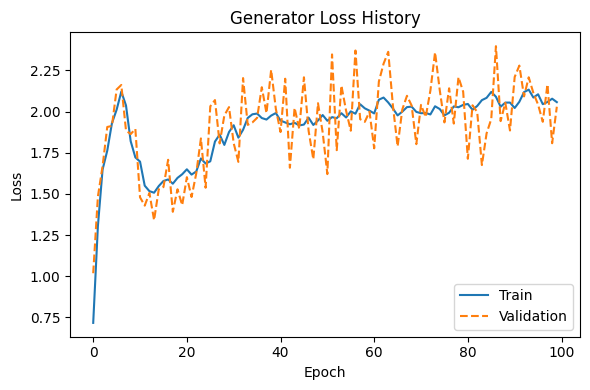

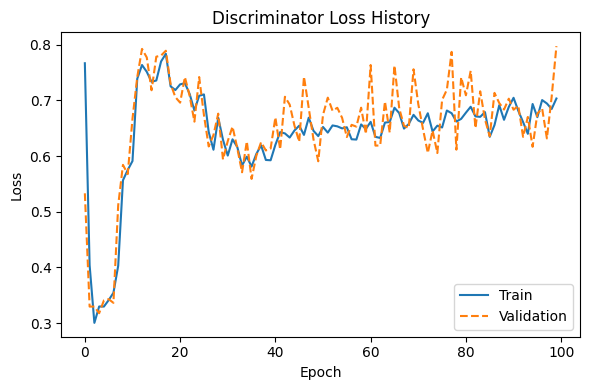

In [ ]:
plot_losses(gan.train_g_loss_history, gan.val_g_loss_history, title="Generator Loss History")
plot_losses(gan.train_d_loss_history, gan.val_d_loss_history, title="Discriminator Loss History")

#####12. Побудувати графік середніх ймовірностей реальних і фальшивих зображень, які розраховано дискримінатором на кожній ітерації. Наскільки відміними вони будуть від значення 0,5 ?

Побудуємо також графік середніх ймовірностей реальних і фальшивих зображень, які розраховано дискримінатором на кожній ітерації.

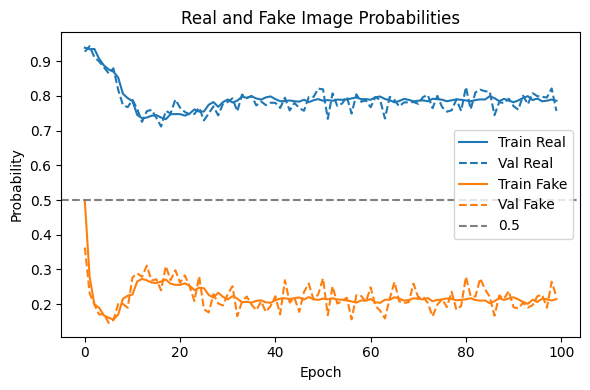

In [ ]:
def plot_probs(train_real_probs, train_fake_probs,
               val_real_probs=None, val_fake_probs=None,
               title="Real and Fake Image Probabilities"):
  plt.figure(figsize=(6, 4))

  plt.plot(train_real_probs, label="Train Real", color="tab:blue")
  if val_real_probs is not None:
    plt.plot(val_real_probs, label="Val Real", linestyle="--", color="tab:blue")

  plt.plot(train_fake_probs, label="Train Fake", color="tab:orange")
  if val_fake_probs is not None:
    plt.plot(val_fake_probs, label="Val Fake", linestyle="--", color="tab:orange")

  plt.axhline(0.5, color="gray", linestyle="--", label="0.5")

  plt.title(title)
  plt.xlabel("Epoch")
  plt.ylabel("Probability")
  plt.legend()
  plt.tight_layout()
  plt.show()

plot_probs(gan.train_real_prob_history, gan.train_fake_prob_history, gan.val_real_prob_history, gan.val_fake_prob_history)

Бачимо, що середні ймовірності реальних зображень мають значення більше ніж 0.5, а середні ймовірності фальшивих зображень - менші за 0.5. Вони відрізняються від 0.5 приблизно однаково (на величину 0.3).

#####13. Надрукувати кілька зображень, які будуються генератором на перших і останніх епохах навчання.

Відобразимо зображення, згенеровані на 1, 5, 10, 90, 95 та 100 епохах.

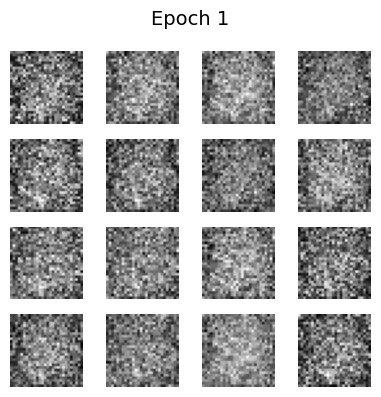

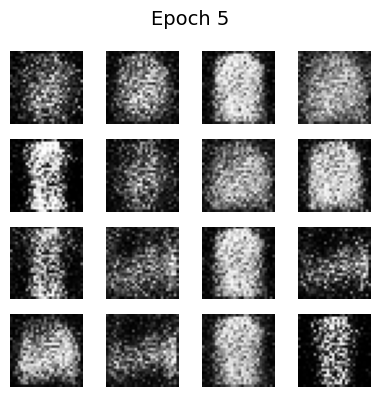

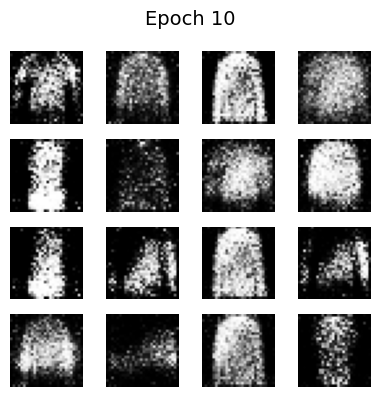

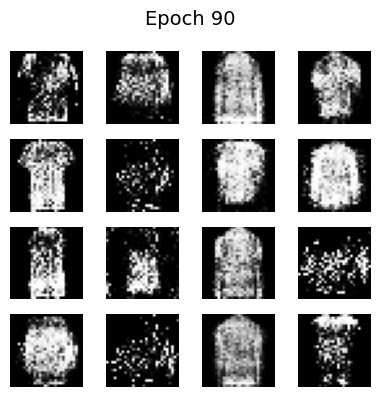

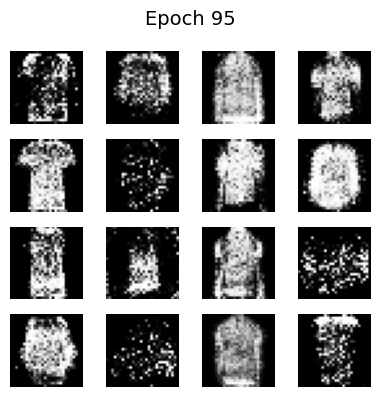

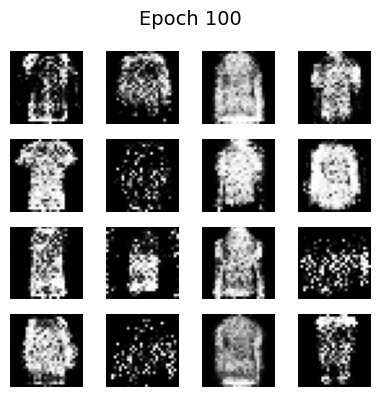

In [ ]:
plot_generated(
    monitor_callback.generated_images_per_epoch,
    plot_epochs=[0, 4, 9, 89, 94, 99]
)

#####14. Оцінити якість побудованої моделі GAN.

Результати тренування свідчать, що GAN-модель навчається і виходить на деяку стабілізацію, але все ж спостерігаються ознаки нестійкості, характерні для звичайного GAN.

Генератор постійно покращується до 30 епохи - це видно по збільшенню generator_loss (велика втрата часто свідчить, що дискримінатор сильний). Генератор поступово вчиться, хоча йому важко обманути дискримінатор. На пізніших епохах спостерігається коливання без суттєвого покращення.

Втрата дискримінатора спочатку різко падає, потім стабілізується в межах 0.6-0.7, що свідчить про стабільне навчання. fake_prob поступово спадає до значень 0.15-0.25, тобто дискримінатор ефективно виявляє фейки. Ймовірність real_prob на валідації коливається в межах 0.73-0.79, тобто дискримінатор досить впевнено впізнає справжні зображення.

Згенеровані зображення демонструють поступове покращення протягом 100 епох: з початкового шуму формується розпізнаваний зміст. Хоча зображення виглядають ніби складені з точок і подекуди переважає темний фон, спостерігається чітка відмінність між фоном і обрисами об'єктів - виразніша, ніж у варіаційного автокодувальника.

Для покращення результатів можна спробувати навчати дискримінатор частіше, ніж генератор або додати регуляризацію.

####**Частина 3**

#####15. Побудувати глибоку згорткову модель DCGAN:
* Генератор - глибока згорткова мережа, включає кілька шарів транспонованої згортки і шари пакетної нормалізації між ними.
* Дискримінатор - глибока згорткова мережа, включає кілька шарів традиційної згортки і шари пакетної нормалізації між ними.
* Використати ті самі функції втрат і процедуру навчання, створені для попередньої простої моделі GAN.
* Змість бінарної перехресної ентропії використати функцію втрат на основі відстані Вассерштейна.
* Використати штраф градієнта (gradient penalty, GP).  
За умови двох останніх пунктів модель отримала назву WGAN-with-GP.

Створимо клас генератора DCGANGenerator. Це глибока згорткова мережа з кількома шарами транспонованої згортки. Між ними застосовуються шари пакетної нормалізації. Використано функції активації Leaky ReLU.

In [ ]:
class DCGANGenerator(tf.keras.Model):
  def __init__(self, z_size=20, output_size=(28, 28, 1),
               n_filters=128, n_blocks=2):
    super().__init__()
    self.z_size = z_size
    self.output_size = output_size
    self.n_filters = n_filters
    self.n_blocks = n_blocks

    size_factor = 2 ** self.n_blocks
    hidden_size = (
        output_size[0] // size_factor,
        output_size[1] // size_factor
    )

    self.model_layers = [
        keras.layers.Dense(
            units=self.n_filters * hidden_size[0] * hidden_size[1],
            use_bias=False),
        keras.layers.BatchNormalization(),
        keras.layers.LeakyReLU(),
        keras.layers.Reshape((hidden_size[0], hidden_size[1],
                              self.n_filters)),
        keras.layers.Conv2DTranspose(
            filters=self.n_filters, kernel_size=5, strides=1,
            padding="same", use_bias=False),
        keras.layers.BatchNormalization(),
        keras.layers.LeakyReLU(),
    ]

    nf = self.n_filters
    for _ in range(self.n_blocks):
      nf //= 2
      self.model_layers += [
          keras.layers.Conv2DTranspose(
              filters=nf, kernel_size=5, strides=2,
              padding="same", use_bias=False),
          keras.layers.BatchNormalization(),
          keras.layers.LeakyReLU(),
      ]

    self.model_layers.append(
        keras.layers.Conv2DTranspose(
            filters=output_size[2], kernel_size=5, strides=1,
            padding="same", use_bias=False, activation="tanh")
    )

  def call(self, inputs, training=False):
    x = inputs
    for layer in self.model_layers:
      x = layer(x, training=training)
    return x

  def build(self, input_shape):
    x = tf.keras.Input(shape=input_shape[1:])
    self.call(x)
    super().build(input_shape)

Створимо клас дискримінатора DCGANDiscriminator. Це глибока згорткова мережа з кількома шарами традиційної згортки. Між ними застосовуються шари пакетної нормалізації. Використано також Dropout.

In [ ]:
class DCGANDiscriminator(tf.keras.Model):
  def __init__(self, input_size=(28, 28, 1), n_filters=64, n_blocks=2,
               dropout_rate=0.3):
    super().__init__()
    self.input_size = input_size
    self.n_filters = n_filters
    self.n_blocks = n_blocks
    self.dropout_rate = dropout_rate

    self.model_layers = [
        keras.layers.Conv2D(
            filters=self.n_filters, kernel_size=5, strides=1,
            padding="same"),
        keras.layers.BatchNormalization(),
        keras.layers.LeakyReLU()
    ]

    nf = self.n_filters
    for _ in range(self.n_blocks):
      nf *= 2
      self.model_layers += [
          keras.layers.Conv2D(
              filters=nf, kernel_size=5, strides=2, padding="same"),
          keras.layers.BatchNormalization(),
          keras.layers.LeakyReLU(),
          keras.layers.Dropout(self.dropout_rate)
      ]

    self.model_layers += [
        keras.layers.Conv2D(filters=1, kernel_size=7, padding="valid"),
        keras.layers.Reshape((1,))
    ]

  def call(self, inputs, training=False):
    x = inputs
    for layer in self.model_layers:
      x = layer(x, training=training)
    return x

  def build(self, input_shape):
    x = tf.keras.Input(shape=input_shape[1:])
    self.call(x)
    super().build(input_shape)

Побудуємо модель WGANwithGP. Реалізуємо прямий прохід генератора і дискримінатора по мережі під час тренування та валідації (тестування) так само, як і для моделі GAN, але з використанням штрафу градієнта. Змість бінарної перехресної ентропії використано функцію втрат на основі відстані Вассерштейна.

In [ ]:
class WGANwithGP(keras.Model):
  def __init__(self, lambda_gp=10.0):
    super().__init__()
    self.lambda_gp = lambda_gp

    self.generator = DCGANGenerator(z_size=20, output_size=(28, 28, 1), n_filters=128, n_blocks=2)
    self.discriminator = DCGANDiscriminator(input_size=(28, 28, 1), n_filters=64, n_blocks=2)

    self.g_loss_tracker = keras.metrics.Mean(name="generator_loss")
    self.d_loss_tracker = keras.metrics.Mean(name="discriminator_loss")
    self.d_loss_real_tracker = keras.metrics.Mean(name="d_loss_real")
    self.d_loss_fake_tracker = keras.metrics.Mean(name="d_loss_fake")
    self.real_prob_tracker = keras.metrics.Mean(name="real_prob")
    self.fake_prob_tracker = keras.metrics.Mean(name="fake_prob")

  def _update_trackers(self, real_logits, fake_logits, d_loss_real, d_loss_fake, g_loss, d_loss):
    real_probs = tf.sigmoid(real_logits)
    fake_probs = tf.sigmoid(fake_logits)
    self.real_prob_tracker.update_state(tf.reduce_mean(real_probs))
    self.fake_prob_tracker.update_state(tf.reduce_mean(fake_probs))
    self.d_loss_real_tracker.update_state(d_loss_real)
    self.d_loss_fake_tracker.update_state(d_loss_fake)
    self.g_loss_tracker.update_state(g_loss)
    self.d_loss_tracker.update_state(d_loss)

  @property
  def metrics(self):
    return [
        self.g_loss_tracker, self.d_loss_tracker,
        self.d_loss_real_tracker, self.d_loss_fake_tracker,
        self.real_prob_tracker, self.fake_prob_tracker
    ]

  def compile(self, g_optimizer, d_optimizer):
    super().compile()
    self.g_optimizer = g_optimizer
    self.d_optimizer = d_optimizer

  def train_step(self, data):
    random_latent_vectors, real_images = data

    with tf.GradientTape() as d_tape, tf.GradientTape() as g_tape:
      generated_images = self.generator(random_latent_vectors, training=True)

      d_critics_real = self.discriminator(real_images, training=True)
      d_critics_fake = self.discriminator(generated_images, training=True)

      # Generator loss
      g_loss = -tf.math.reduce_mean(d_critics_fake)

      # Discriminator loss
      d_loss_real = -tf.math.reduce_mean(d_critics_real)
      d_loss_fake =  tf.math.reduce_mean(d_critics_fake)
      d_loss = d_loss_real + d_loss_fake

      # Gradient penalty
      with tf.GradientTape() as gp_tape:
        alpha = tf.random.uniform([d_critics_real.shape[0], 1, 1, 1], minval=0.0, maxval=1.0)
        interpolated_images = alpha * real_images + (1 - alpha) * generated_images
        gp_tape.watch(interpolated_images)
        d_critics_intp = self.discriminator(interpolated_images)

      grads_intp = gp_tape.gradient(d_critics_intp, [interpolated_images, ])[0]
      grads_intp_l2 = tf.sqrt(tf.reduce_sum(tf.square(grads_intp), axis=[1, 2, 3]))
      grad_penalty = tf.reduce_mean(tf.square(grads_intp_l2 - 1.0))

      d_loss = d_loss + self.lambda_gp * grad_penalty

    d_grads = d_tape.gradient(d_loss, self.discriminator.trainable_variables)
    self.d_optimizer.apply_gradients(zip(d_grads, self.discriminator.trainable_variables))

    g_grads = g_tape.gradient(g_loss, self.generator.trainable_variables)
    self.g_optimizer.apply_gradients(zip(g_grads, self.generator.trainable_variables))

    self._update_trackers(d_critics_real, d_critics_fake, d_loss_real, d_loss_fake, g_loss, d_loss)

    return {
        "generator_loss": self.g_loss_tracker.result(),
        "discriminator_loss": self.d_loss_tracker.result(),
        "d_loss_real": self.d_loss_real_tracker.result(),
        "d_loss_fake": self.d_loss_fake_tracker.result(),
        "real_prob": self.real_prob_tracker.result(),
        "fake_prob": self.fake_prob_tracker.result()
    }

  def test_step(self, data):
    random_latent_vectors, real_images = data

    generated_images = self.generator(random_latent_vectors, training=True)

    d_critics_real = self.discriminator(real_images, training=True)
    d_critics_fake = self.discriminator(generated_images, training=True)

    # Generator loss
    g_loss = -tf.math.reduce_mean(d_critics_fake)

    # Discriminator loss
    d_loss_real = -tf.math.reduce_mean(d_critics_real)
    d_loss_fake =  tf.math.reduce_mean(d_critics_fake)
    d_loss = d_loss_real + d_loss_fake

    self._update_trackers(d_critics_real, d_critics_fake, d_loss_real, d_loss_fake, g_loss, d_loss)

    return {
        "generator_loss": self.g_loss_tracker.result(),
        "discriminator_loss": self.d_loss_tracker.result(),
        "d_loss_real": self.d_loss_real_tracker.result(),
        "d_loss_fake": self.d_loss_fake_tracker.result(),
        "real_prob": self.real_prob_tracker.result(),
        "fake_prob": self.fake_prob_tracker.result()
    }

  def generate_images(self, z_input):
    generated = self.generator(z_input, training=False)
    return tf.reshape(generated, (-1, 28, 28))


class WGANwithGPLossHistoryCallback(keras.callbacks.Callback):
  def on_train_begin(self, logs=None):
    self.model.train_g_loss_history = []
    self.model.train_d_loss_history = []
    self.model.train_d_loss_real_history = []
    self.model.train_d_loss_fake_history = []
    self.model.val_g_loss_history = []
    self.model.val_d_loss_history = []
    self.model.val_d_loss_real_history = []
    self.model.val_d_loss_fake_history = []

  def on_epoch_end(self, epoch, logs=None):
    self.model.train_g_loss_history.append(logs["generator_loss"])
    self.model.train_d_loss_history.append(logs["discriminator_loss"])
    self.model.train_d_loss_real_history.append(logs["d_loss_real"])
    self.model.train_d_loss_fake_history.append(logs["d_loss_fake"])
    self.model.val_g_loss_history.append(logs.get("val_generator_loss"))
    self.model.val_d_loss_history.append(logs.get("val_discriminator_loss"))
    self.model.val_d_loss_real_history.append(logs.get("val_d_loss_real"))
    self.model.val_d_loss_fake_history.append(logs.get("val_d_loss_fake"))

#####16. Наведені вище кроки 7 - 14 повторити для моделі WGAN-with-GP.  Використати оптимізатор Adam.

Завантажимо та передобробимо набір даних Fashion MNIST. Розділимо на тренувальну, валідаційну та тестову вибірки. У роботі використовуватимемо вектори, які мають рівномірний (uniform) розподіл. Створимо вектори та сформуємо остаточні набори даних. Створимо міні-батчі із зображеннями.

In [ ]:
# Load data
(X_full_train, y_full_train), (X_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()

# Convert to float32 and scale into [-1, 1]
X_full_train = X_full_train.astype(np.float32).reshape((-1, 28, 28, 1))
X_test = X_test.astype(np.float32).reshape((-1, 28, 28, 1))
X_full_train = X_full_train / 255.0 * 2.0 - 1.0
X_test = X_test / 255.0 * 2.0 - 1.0

# Split into train/val
X_train, X_valid, y_train, y_valid = train_test_split(
    X_full_train, y_full_train.astype(np.int32), test_size=0.1, random_state=SEED)

# Wrap into tf.data.Dataset
train_gan_ds = tf.data.Dataset.from_tensor_slices(X_train)
val_gan_ds = tf.data.Dataset.from_tensor_slices(X_valid)
test_gan_ds = tf.data.Dataset.from_tensor_slices(X_test)

# Form final datasets for GAN and WGANwithGP
train_gan_ds = train_gan_ds.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
train_gan_ds = train_gan_ds.shuffle(10000, seed=SEED)
train_gan_ds = train_gan_ds.batch(BATCH_SIZE, drop_remainder=True).prefetch(tf.data.AUTOTUNE)

val_gan_ds = val_gan_ds.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
val_gan_ds = val_gan_ds.batch(BATCH_SIZE, drop_remainder=True).prefetch(tf.data.AUTOTUNE)

test_gan_ds = test_gan_ds.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
test_gan_ds = test_gan_ds.batch(BATCH_SIZE, drop_remainder=True).prefetch(tf.data.AUTOTUNE)

Відобразимо пошарову архітектуру генератора та дискримінатора.

In [ ]:
wgangp = WGANwithGP()
wgangp.generator.build(input_shape=(None, 20))
wgangp.generator.summary()
print()
wgangp.discriminator.build(input_shape=(None, 28, 28, 1))
wgangp.discriminator.summary()

Model: "dcgan_generator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_15 (Dense)                │ (None, 6272)           │       125,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 6272)           │        25,088 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 7, 7, 128)      │       409,600 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_5 (LeakyReLU)       │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 14, 14, 64)     │       204,800 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_6 (LeakyReLU)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 28, 28, 32)     │        51,200 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_7 (LeakyReLU)       │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_3              │ (None, 28, 28, 1)      │           800 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 817,824 (3.12 MB)

 Trainable params: 804,832 (3.07 MB)

 Non-trainable params: 12,992 (50.75 KB)

Model: "dcgan_discriminator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 64)     │         1,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 28, 28, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_8 (LeakyReLU)       │ (None, 28, 28, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 128)    │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 14, 14, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_9 (LeakyReLU)       │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 256)      │       819,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 7, 7, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_10 (LeakyReLU)      │ (None, 7, 7, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 7, 7, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 1, 1, 1)        │        12,545 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_1 (Reshape)             │ (None, 1)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,040,385 (3.97 MB)

 Trainable params: 1,039,489 (3.97 MB)

 Non-trainable params: 896 (3.50 KB)

Проведемо навчання генератора та дискримінатора з окремими оптимізаторами Adam на 100 епохах. Після кожної епохи зберігатимемо згенеровані зображення та інші показники моделі. Виконуватимемо збереження самої моделі кожні 25 епох.

In [ ]:
LEARNING_RATE = 0.0002

wgangp = WGANwithGP()
wgangp.compile(
    g_optimizer=tf.keras.optimizers.Adam(LEARNING_RATE),
    d_optimizer=tf.keras.optimizers.Adam(LEARNING_RATE),
)
loss_history_callback = WGANwithGPLossHistoryCallback()
prob_history_callback = GANProbHistoryCallback()
monitor_callback = GANMonitor()
checkpoint_callback = EpochCheckpoint(
    save_every=25,
    filepath="checkpoints/wgangp_epoch_{epoch:03d}.h5"
)

wgangp.fit(
    train_gan_ds, epochs=100, validation_data=val_gan_ds,
    callbacks=[loss_history_callback, prob_history_callback, monitor_callback, checkpoint_callback], verbose=1)

Epoch 1/100
843/843 ━━━━━━━━━━━━━━━━━━━━ 84s 78ms/step - d_loss_fake: -131.5308 - d_loss_real: -128.0751 - discriminator_loss: -206.6711 - fake_prob: 0.1260 - generator_loss: 131.5308 - real_prob: 0.9825 - val_d_loss_fake: -258.3230 - val_d_loss_real: -121.8118 - val_discriminator_loss: -380.1348 - val_fake_prob: 2.9981e-23 - val_generator_loss: 258.3230 - val_real_prob: 0.9463
Epoch 2/100
843/843 ━━━━━━━━━━━━━━━━━━━━ 63s 67ms/step - d_loss_fake: -205.9713 - d_loss_real: -115.1666 - discriminator_loss: -36.6112 - fake_prob: 0.0154 - generator_loss: 205.9713 - real_prob: 0.8360 - val_d_loss_fake: -261.6495 - val_d_loss_real: -234.4406 - val_discriminator_loss: -496.0902 - val_fake_prob: 0.0000e+00 - val_generator_loss: 261.6495 - val_real_prob: 1.0000
Epoch 3/100
843/843 ━━━━━━━━━━━━━━━━━━━━ 58s 68ms/step - d_loss_fake: -259.6501 - d_loss_real: -196.6273 - discriminator_loss: -314.2725 - fake_prob: 0.0044 - generator_loss: 259.6501 - real_prob: 0.9748 - val_d_loss_fake: -258.7817 - val_


Model saved at epoch 25 to checkpoints/wgangp_epoch_025.h5
843/843 ━━━━━━━━━━━━━━━━━━━━ 58s 68ms/step - d_loss_fake: -377.3811 - d_loss_real: 196.2563 - discriminator_loss: 7.2828 - fake_prob: 0.0933 - generator_loss: 377.3811 - real_prob: 0.2335 - val_d_loss_fake: -145.1264 - val_d_loss_real: 124.8648 - val_discriminator_loss: -20.2617 - val_fake_prob: 3.9372e-36 - val_generator_loss: 145.1264 - val_real_prob: 3.2298e-16
Epoch 26/100
843/843 ━━━━━━━━━━━━━━━━━━━━ 82s 68ms/step - d_loss_fake: -272.0163 - d_loss_real: 199.3112 - discriminator_loss: -70.9950 - fake_prob: 0.0948 - generator_loss: 272.0163 - real_prob: 0.1610 - val_d_loss_fake: 11.1751 - val_d_loss_real: -52.2347 - val_discriminator_loss: -41.0595 - val_fake_prob: 0.7029 - val_generator_loss: -11.1751 - val_real_prob: 0.9896
Epoch 27/100
843/843 ━━━━━━━━━━━━━━━━━━━━ 57s 67ms/step - d_loss_fake: -285.4377 - d_loss_real: 205.7702 - discriminator_loss: -76.7722 - fake_prob: 0.0858 - generator_loss: 285.4377 - real_prob: 0.260


Model saved at epoch 50 to checkpoints/wgangp_epoch_050.h5
843/843 ━━━━━━━━━━━━━━━━━━━━ 82s 68ms/step - d_loss_fake: -1339.4572 - d_loss_real: 1211.0813 - discriminator_loss: -107.8128 - fake_prob: 0.0000e+00 - generator_loss: 1339.4572 - real_prob: 0.0000e+00 - val_d_loss_fake: -1161.4021 - val_d_loss_real: 1135.5245 - val_discriminator_loss: -25.8776 - val_fake_prob: 0.0000e+00 - val_generator_loss: 1161.4021 - val_real_prob: 0.0000e+00
Epoch 51/100
843/843 ━━━━━━━━━━━━━━━━━━━━ 57s 68ms/step - d_loss_fake: -814.7569 - d_loss_real: 718.3541 - discriminator_loss: -94.8768 - fake_prob: 1.7656e-04 - generator_loss: 814.7569 - real_prob: 0.0137 - val_d_loss_fake: -209.6686 - val_d_loss_real: 76.5488 - val_discriminator_loss: -133.1198 - val_fake_prob: 1.9365e-15 - val_generator_loss: 209.6686 - val_real_prob: 0.0628
Epoch 52/100
843/843 ━━━━━━━━━━━━━━━━━━━━ 82s 68ms/step - d_loss_fake: -936.4316 - d_loss_real: 804.8251 - discriminator_loss: -129.4919 - fake_prob: 0.0482 - generator_loss:


Model saved at epoch 75 to checkpoints/wgangp_epoch_075.h5
843/843 ━━━━━━━━━━━━━━━━━━━━ 82s 68ms/step - d_loss_fake: -3505.4763 - d_loss_real: 3172.6475 - discriminator_loss: -324.1008 - fake_prob: 0.1441 - generator_loss: 3505.4763 - real_prob: 0.2012 - val_d_loss_fake: -2605.4685 - val_d_loss_real: 2270.1257 - val_discriminator_loss: -335.3421 - val_fake_prob: 0.0000e+00 - val_generator_loss: 2605.4685 - val_real_prob: 0.0000e+00
Epoch 76/100
843/843 ━━━━━━━━━━━━━━━━━━━━ 82s 68ms/step - d_loss_fake: -4600.0923 - d_loss_real: 4125.7905 - discriminator_loss: -378.7972 - fake_prob: 0.0000e+00 - generator_loss: 4600.0923 - real_prob: 0.0000e+00 - val_d_loss_fake: -4500.6870 - val_d_loss_real: 3421.8296 - val_discriminator_loss: -1078.8579 - val_fake_prob: 0.0000e+00 - val_generator_loss: 4500.6870 - val_real_prob: 0.0000e+00
Epoch 77/100
843/843 ━━━━━━━━━━━━━━━━━━━━ 57s 68ms/step - d_loss_fake: -5041.1509 - d_loss_real: 4515.5547 - discriminator_loss: -466.2763 - fake_prob: 0.0000e+00 -


Model saved at epoch 100 to checkpoints/wgangp_epoch_100.h5
843/843 ━━━━━━━━━━━━━━━━━━━━ 57s 68ms/step - d_loss_fake: -9237.3311 - d_loss_real: 7113.0171 - discriminator_loss: -1871.4468 - fake_prob: 0.0000e+00 - generator_loss: 9237.3311 - real_prob: 1.0579e-04 - val_d_loss_fake: -9766.7969 - val_d_loss_real: 6944.2202 - val_discriminator_loss: -2822.5769 - val_fake_prob: 0.0000e+00 - val_generator_loss: 9766.7969 - val_real_prob: 0.0000e+00


Відобразимо графіки втрат генератора та дискримінатора протягом навчання.

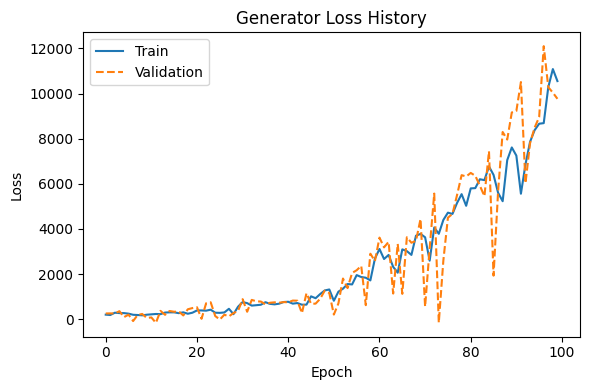

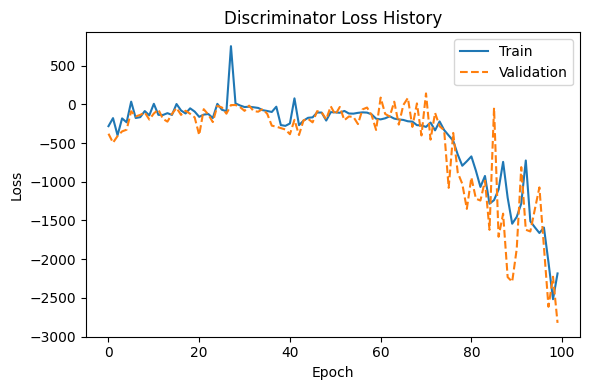

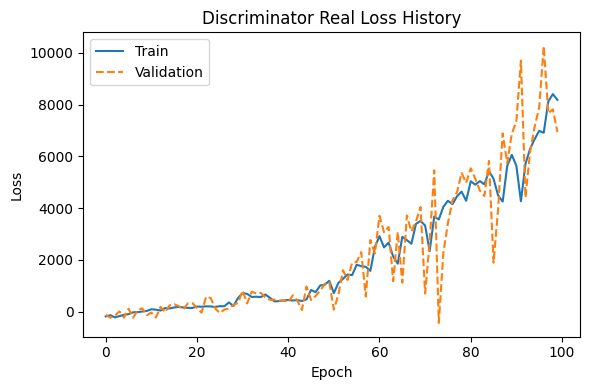

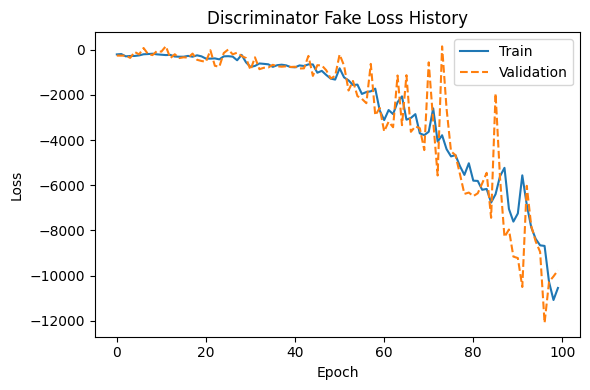

In [ ]:
plot_losses(wgangp.train_g_loss_history, wgangp.val_g_loss_history, title="Generator Loss History")
plot_losses(wgangp.train_d_loss_history, wgangp.val_d_loss_history, title="Discriminator Loss History")
plot_losses(wgangp.train_d_loss_real_history, wgangp.val_d_loss_real_history, title="Discriminator Real Loss History")
plot_losses(wgangp.train_d_loss_fake_history, wgangp.val_d_loss_fake_history, title="Discriminator Fake Loss History")

Побудуємо також графік середніх ймовірностей реальних і фальшивих зображень, які розраховано дискримінатором на кожній ітерації.

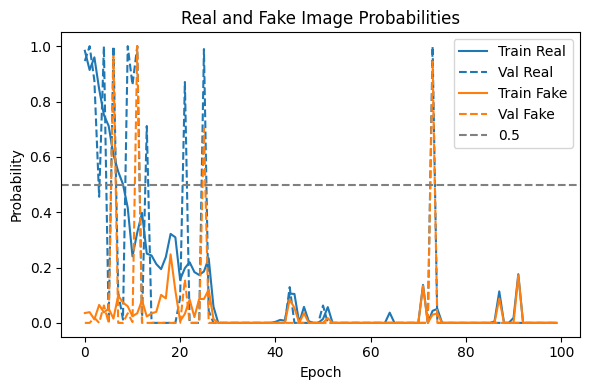

In [ ]:
plot_probs(wgangp.train_real_prob_history, wgangp.train_fake_prob_history, wgangp.val_real_prob_history, wgangp.val_fake_prob_history)

Відобразимо зображення, згенеровані на 1, 5, 10, 90, 95 та 100 епохах.

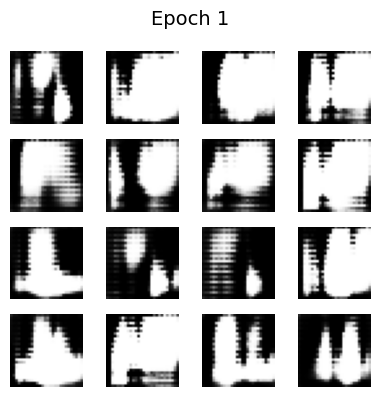

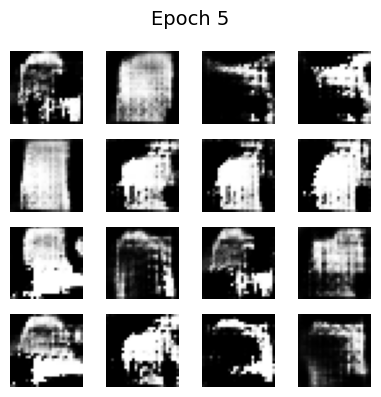

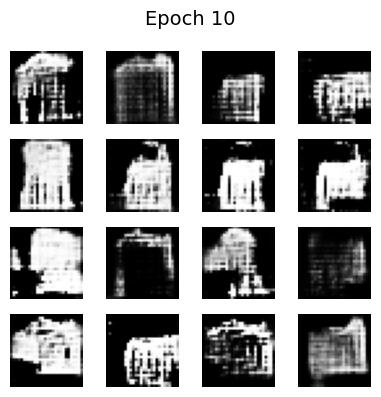

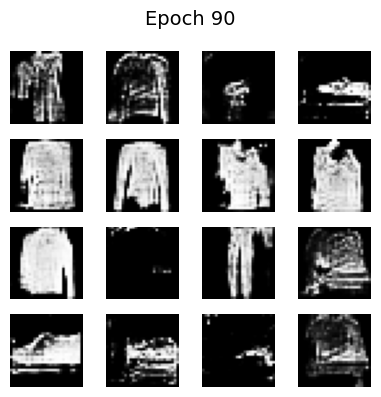

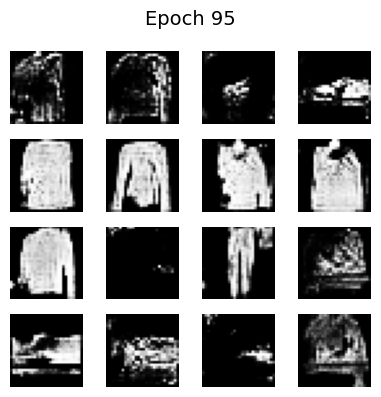

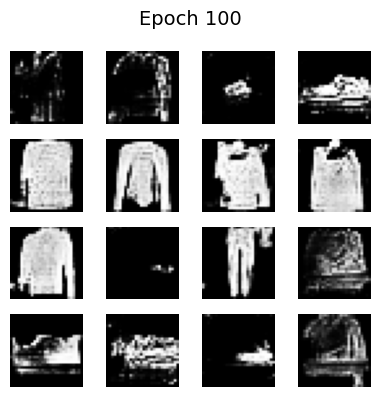

In [ ]:
plot_generated(
    monitor_callback.generated_images_per_epoch,
    plot_epochs=[0, 4, 9, 89, 94, 99]
)

#####17. Порівняти якість зображень сгенерованих всіма побудованими моделями: варіаційним автокодувальником, простою GAN та моделлю WGAN-with-GP.  
Які висновки можна зробити на основі аналізу графіків втрат генератора і дискримінатора побудованих моделей GAN?

Втрата генератора збільшується, що є очікуваною поведінкою для WGAN. Втрата дискримінатора має великі негативні значення, що свідчить про те, що дискримінатор добре відрізняє справжнє зображення від підробленого.

При тренуванні WGANwithGP спостерігаються ознаки дисбалансу між генератором і дискримінатором. Валідаційна втрата генератора значно зростає. Це вказує на перевагу дискримінатора, який занадто легко розпізнає фейкові зразки. real_prob та fake_prob періодично падають до нуля або зростають аномально, що свідчить про втрату балансу, що може бути результатом занадто потужного дискримінатора. Великі значення d_loss_real можеуть свідчити про те, що реальні зразки іноді оцінюються як фейкові.

Згенеровані зображення покращуються протягом 100 епох навчання. Можна помітити, що результат на 90 епосі є візуально кращим за результат на 100 - більше предметів можна розпізнати. Зображення, згенеровані на 100 епосі є різними, частина з них є неповною.

Для покращення результатів можна спробувати зменшити кількість епох навчання або learning rate генератора.

##Висновок

У ході лабораторної роботи було реалізовано та проаналізовано три типи генеративних моделей: варіаційний автокодувальник, просту модель GAN і вдосконалений варіант з функцією втрат на основі відстані Вассерштейна з градієнтним штрафом WGANwithGP.

Варіаційний автокодувальник продемонстрував стабільне навчання, зменшення втрат і збереження нормального розподілу латентного простору, однак якість згенерованих зображень залишалася посередньою: на кожному з них простежуються елементи кількох предметів без чіткої структури. GAN-модель продемонструвала найкращі візуальні результати серед трьох підходів: зображення мали чіткі обриси і краще відділення об'єкта від фону. Під час навчання GAN спостерігались коливання втрат та ймовірностей, характерні для змагання між генератором і дискримінатором. WGANwithGP, попри вдосконалену функцію втрат, не досяг візуально якіснішого результату через надмірну перевагу дискримінатора, що призводило до дисбалансу і погіршення якості генерації на пізніх етапах.

Таким чином, за результатами експериментів, найкращі результати з точки зору візуального сприйняття були отримані за допомогою звичайного GAN.
